# GT_VOL与PRED_VOL 可视化对比

2026-03-25 22:46:16.045 (   1.338s) [    7F1C0F179280]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
/root/miniconda3/envs/r2gs/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


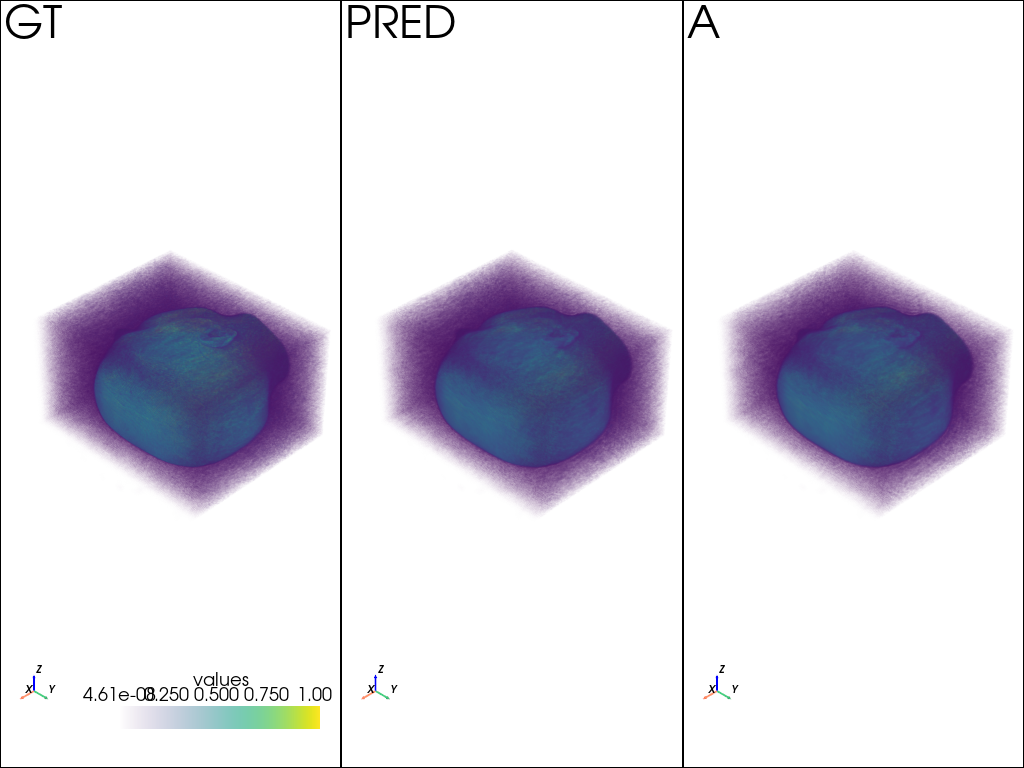

In [1]:
import pyvista as pv
import numpy as  np

gt_path = 'MRIdata/output_2026_3_14_2/point_cloud/iteration_1000/vol_gt.npy'
pred_path = 'MRIdata/output_2026_3_14_2/point_cloud/iteration_1000/vol_pred.npy'


gt_vol = np.load('MRIdata/acc_rate2/vol_gt_unsampled.npy')
pred_vol = np.load('MRIdata/acc_rate4/vol_gt_unsampled.npy')
a = np.load("MRIdata/acc_rate6/vol_gt_unsampled.npy")

plotter = pv.Plotter(shape=(1,3))
plotter.subplot(0,0)
plotter.add_volume(gt_vol[:,:,:])
plotter.add_text('GT')
plotter.add_axes()

plotter.subplot(0,1)
plotter.add_volume(pred_vol[:,:,:])
plotter.add_text('PRED')
plotter.add_axes()

plotter.subplot(0,2)
plotter.add_volume(a[:,:,:])
plotter.add_text('A')
plotter.add_axes()

plotter.show()

# 重建指标(PSNR)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import torch,json
pred_path = "MRIdata/outputs/exp_0317_1538_iter1000_L2loss_under/point_cloud/iteration_1000/vol_pred.npy"
gt_path = "MRIdata/under/vol_gt.npy"

# pred_path = "MRIdata/outputs/exp_0316_1210_iter1000/point_cloud/iteration_1000/vol_pred.npy"
# gt_path = "MRIdata/outputs/exp_0316_1210_iter1000/point_cloud/iteration_1000/vol_gt.npy"

gt = np.load(gt_path)
pred = np.load(pred_path)
print(gt.shape)
print(pred.max())

def mse(img1, img2, mask=None):
    """MSE error

    Args:
        img1 (_type_): [b, c, h, w]
        img2 (_type_): [b, c, h, w]
        mask (_type_, optional): [b, c, h, w]. Defaults to None.

    Returns:
        _type_: _description_
    """
    n_channel = img1.shape[1]
    if mask is not None:
        img1 = img1.flatten(1)
        img2 = img2.flatten(1)

        mask = mask.flatten(1).repeat(1, n_channel)
        mask = torch.where(mask != 0, True, False)

        mse = torch.stack(
            [
                (((img1[i, mask[i]] - img2[i, mask[i]])) ** 2).mean(0, keepdim=True)
                for i in range(img1.shape[0])
            ],
            dim=0,
        )

    else:
        mse = (((img1 - img2)) ** 2).reshape(img1.shape[0], -1).mean(1, keepdim=True)
    return mse
def psnr(img1, img2, mask=None, pixel_max=1.0):
    """PSNR

    Args:
        img1 (_type_): [b, c, h, w]
        img2 (_type_): [b, c, h, w]
        mask (_type_, optional): [b, c, h, w]. Defaults to None.

    Returns:
        _type_: _description_
    """
    mse_out = mse(img1, img2, mask)
    psnr_out = 10 * torch.log10(pixel_max**2 / mse_out.float())
    if mask is not None:
        if torch.isinf(psnr_out).any():
            print(mse_out.mean(), psnr_out.mean())
            psnr_out = 10 * torch.log10(pixel_max**2 / mse_out.float())
            psnr_out = psnr_out[~torch.isinf(psnr_out)]

    return psnr_out

psnr_list = {}
for i in range(len(gt)):
    psnr_list[f"slice_{i+1}"] = psnr(torch.from_numpy(gt[i])[None,None],torch.from_numpy(pred[i])[None  ,None],pixel_max=1.0).squeeze(0).item()
print(psnr_list)
path = 'MRIdata/outputs/exp_0317_1538_iter1000_L2loss_under/eval/psnr2d.yml'
with open(path,'w',encoding='utf-8') as f:
    json.dump(psnr_list,f,indent=4)

(261, 350, 350)
1.435179
{'slice_1': 25.216861724853516, 'slice_2': 25.712034225463867, 'slice_3': 25.931127548217773, 'slice_4': 26.175151824951172, 'slice_5': 26.336105346679688, 'slice_6': 26.515827178955078, 'slice_7': 26.769025802612305, 'slice_8': 26.9091796875, 'slice_9': 26.932010650634766, 'slice_10': 26.893394470214844, 'slice_11': 26.858827590942383, 'slice_12': 26.994829177856445, 'slice_13': 26.870750427246094, 'slice_14': 26.885225296020508, 'slice_15': 26.842815399169922, 'slice_16': 26.72940444946289, 'slice_17': 26.810501098632812, 'slice_18': 26.92340087890625, 'slice_19': 26.979415893554688, 'slice_20': 26.930606842041016, 'slice_21': 26.90597915649414, 'slice_22': 26.80046272277832, 'slice_23': 26.782533645629883, 'slice_24': 26.693218231201172, 'slice_25': 26.46807861328125, 'slice_26': 26.58613395690918, 'slice_27': 26.603477478027344, 'slice_28': 26.52425765991211, 'slice_29': 26.48349952697754, 'slice_30': 26.543643951416016, 'slice_31': 26.51415252685547, 'slic

# 重建切片对比

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
pred_path = "MRIdata/outputs/exp_0324_1628_iter10000_l1_under/point_cloud/iteration_10000/vol_pred.npy"
gt_path = "MRIdata/under/vol_gt.npy"
gt = np.load(gt_path)
# gs_pred = np.load(pred_path)
# pocs = np.load('MRIdata/under/pocs_recon.npy')
pred = np.load('MRIdata/outputs/exp_0324_1745_iter10000_l1_under/point_cloud/iteration_3000/vol_pred.npy')

for i in range(25):
    plt.figure()
    plt.subplot(1,2,1)
    plt.axis("off")
    plt.title("GT")
    plt.imshow(gt[i*10,:,:])

    plt.subplot(1,2,2)
    plt.axis("off")
    plt.title("ZERO-FILLED")
    plt.imshow(pred[i*10,:,:])

# plt.subplot(1,4,3)
# plt.axis("off")
# plt.title("POCS")
# plt.imshow(pocs[130])

# plt.subplot(1,4,4)
# plt.axis("off")
# plt.title("GS-PRED")
# plt.imshow(gs_pred[130])
# plt.tight_layout()
    plt.tight_layout()
    plt.show()

# from PIL import Image
# Image.fromarray(gt[130]).save()
# for i in range(5):
#     plt.plot()
#     plt.axis("off")
#     plt.title("GS-PRED")
#     plt.imshow(zero_filled[:,245+i,:])
#     plt.show()


(256, 256, 150)
(256, 256)


(256, 150)

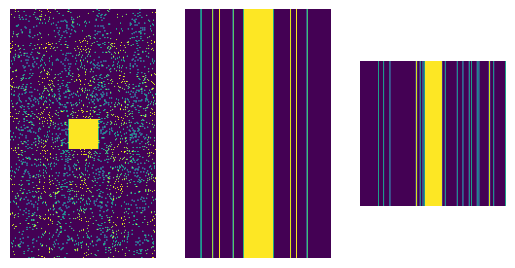

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
mask = np.load('MRIdata/under/mask_3D.npy')
print(mask.shape)
plt.figure()
plt.subplot(1,3,1)
plt.axis("off")
plt.imshow(mask[130,:,:])

plt.subplot(1,3,2)
plt.axis("off")
plt.imshow(mask[:,130,:])

plt.subplot(1,3,3)
plt.axis("off")
plt.imshow(mask[:,:,75])


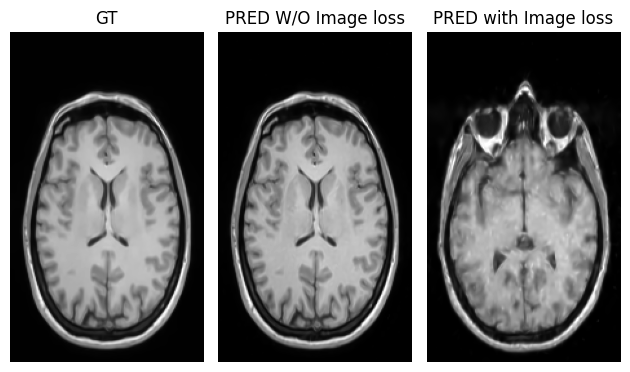

In [53]:
import matplotlib.pyplot as plt
import numpy as np

gt = np.load("MRIdata/outputs/exp_0325_2304_iter3000_2_woi/point_cloud/iteration_3000/vol_pred.npy")
pred_woi = np.load('MRIdata/outputs/exp_0325_2335_iter3000_2_wi/point_cloud/iteration_3000/vol_pred.npy')
pred_wi = np.load("MRIdata/outputs/exp_0326_1838_iter3000_8_wi/point_cloud/iteration_3000/vol_pred.npy")

plt.figure()
plt.subplot(1,3,1)
plt.axis("off")
plt.title("GT")
plt.imshow(gt[150],vmin=0,vmax=1,cmap='gray')

plt.subplot(1,3,2)
plt.axis("off")
plt.title("PRED W/O Image loss")
plt.imshow(pred_woi[150],vmin=0,vmax=1,cmap='gray')

plt.subplot(1,3,3)
plt.axis("off")
plt.title("PRED with Image loss")
plt.imshow(pred_wi[131],vmin=0,vmax=1,cmap='gray')

plt.tight_layout()
plt.show()

In [9]:
a = f"exp_iter_{'image' if True else 'noimage'}"
print(a)

exp_iter_image


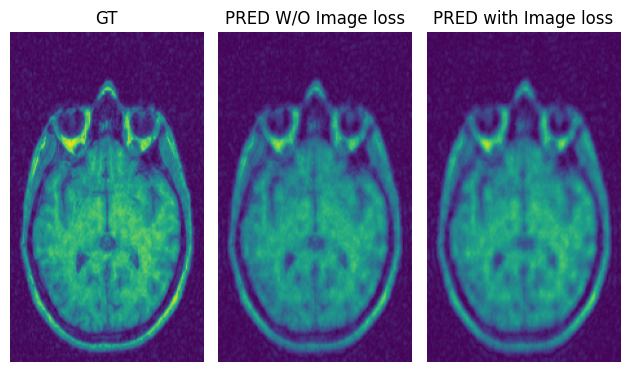

In [2]:
import matplotlib.pyplot as plt
import numpy as np

gt = np.load("MRIdata/acc_rate2/vol_gt_unsampled.npy")
pred_woi = np.load('MRIdata/acc_rate4/vol_gt_unsampled.npy')
pred = np.load("MRIdata/acc_rate6/vol_gt_unsampled.npy")

plt.figure()
plt.subplot(1,3,1)
plt.axis("off")
plt.title("GT")
plt.imshow(gt[131])           

plt.subplot(1,3,2)
plt.axis("off")
plt.title("PRED W/O Image loss")
plt.imshow(pred_woi[131],vmin=0,vmax=1)

plt.subplot(1,3,3)
plt.axis("off")
plt.title("PRED with Image loss")
plt.imshow(pred[131],vmin=0,vmax=1)

plt.tight_layout()
plt.show()

# 3D mask 生成

In [2]:
import numpy as np

np.random.seed(0)

Nx, Ny, Nz = 261, 350, 350
total_lines = int(0.1*350*350)

y = np.arange(-Ny//2, Ny//2)
z = np.arange(-Nz//2, Nz//2)
ky, kz = np.meshgrid(y, z, indexing='ij')
r = np.sqrt(ky**2 + kz**2)

# define gaussian distribution
sigma = 100
probability_map = np.exp(-0.5 * (r**2) / (sigma**2))

# set up full sample area
acs_size = 32 # 设定中心 32x32 为全采样区
acs_mask = (np.abs(ky) < acs_size//2) & (np.abs(kz) < acs_size//2)

probability_map[acs_mask] = 0.0

lines_needed = total_lines - np.sum(acs_mask)

prob_flat = probability_map.flatten()
prob_flat = prob_flat / np.sum(prob_flat) 

# 不重复抽样
chosen_indices = np.random.choice(
    np.arange(Ny * Nz), 
    size=lines_needed, 
    replace=False, 
    p=prob_flat
)
# generate mask
mask_2d = acs_mask.flatten()
mask_2d[chosen_indices] = True
mask_2d = mask_2d.reshape((Ny, Nz)) # 还原回二维

mask_3d = np.zeros((Nx, Ny, Nz), dtype=bool)
mask_3d[:, mask_2d] = True



In [14]:
mask = np.array([[True,True],
                 [False,True]])
a = np.array([[1+1j,1+5j],
              [1+2j,1+3j]])
b = a*mask
print(b)
c = b.copy()
c[1,0]=0
print(c)
c==b

[[1.+1.j 1.+5.j]
 [0.+0.j 1.+3.j]]
[[1.+1.j 1.+5.j]
 [0.+0.j 1.+3.j]]


array([[ True,  True],
       [ True,  True]])

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1,3,1)
plt.title("x")
plt.imshow(mask_3d[0,...])

plt.subplot(1,3,2)
plt.title("y")
plt.imshow(mask_3d[:,175,:])

plt.subplot(1,3,3)
plt.title("z")
plt.imshow(mask_3d[...,175])

plt.show()

print(mask_3d[0,...].shape,mask_3d[:,175,:].shape,mask_3d[...,175].shape)


# POCS


In [16]:
mask = np.load('MRIdata/under/mask_3D.npy')
kspace = np.load('MRIdata/under/kspace_gt.npy')

def fft(image):
    return np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(image), norm='ortho'))

def ifft(kspace):
    return np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(kspace), norm='ortho'))

recon = np.abs(ifft(kspace))

# recon = np.clip(recon, 0, 0.9)  # 将数值限制在 [0, 1] 范围内

def pocs_reconstruction(k_undersampled, mask, n_iterations=50, lambda_reg=0.01):
    """
    POCS (Projection Onto Convex Sets) 迭代重建
    
    参数:
        k_undersampled: 欠采样K空间数据
        mask: 采样掩模
        n_iterations: 迭代次数
        lambda_reg: 正则化参数（软阈值）
    """
    # 初始估计：零填充重建
    x = np.real(ifft(k_undersampled))
    
    for _ in range(n_iterations):
        # 步骤1: 变换到K空间
        k = fft(x)
        
        # 步骤2: 数据一致性投影（保持采样点不变）
        k = k * ~mask + k_undersampled
        
        # 步骤3: 变换回图像域
        x = np.real(ifft(k))
        
        # 步骤4: 稀疏性约束（软阈值）
        x = np.sign(x) * np.maximum(np.abs(x) - lambda_reg, 0)
    
    return x

recon_pocs = pocs_reconstruction(kspace, mask, n_iterations=50, lambda_reg=0.01)



/root/miniconda3/envs/r2gs/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


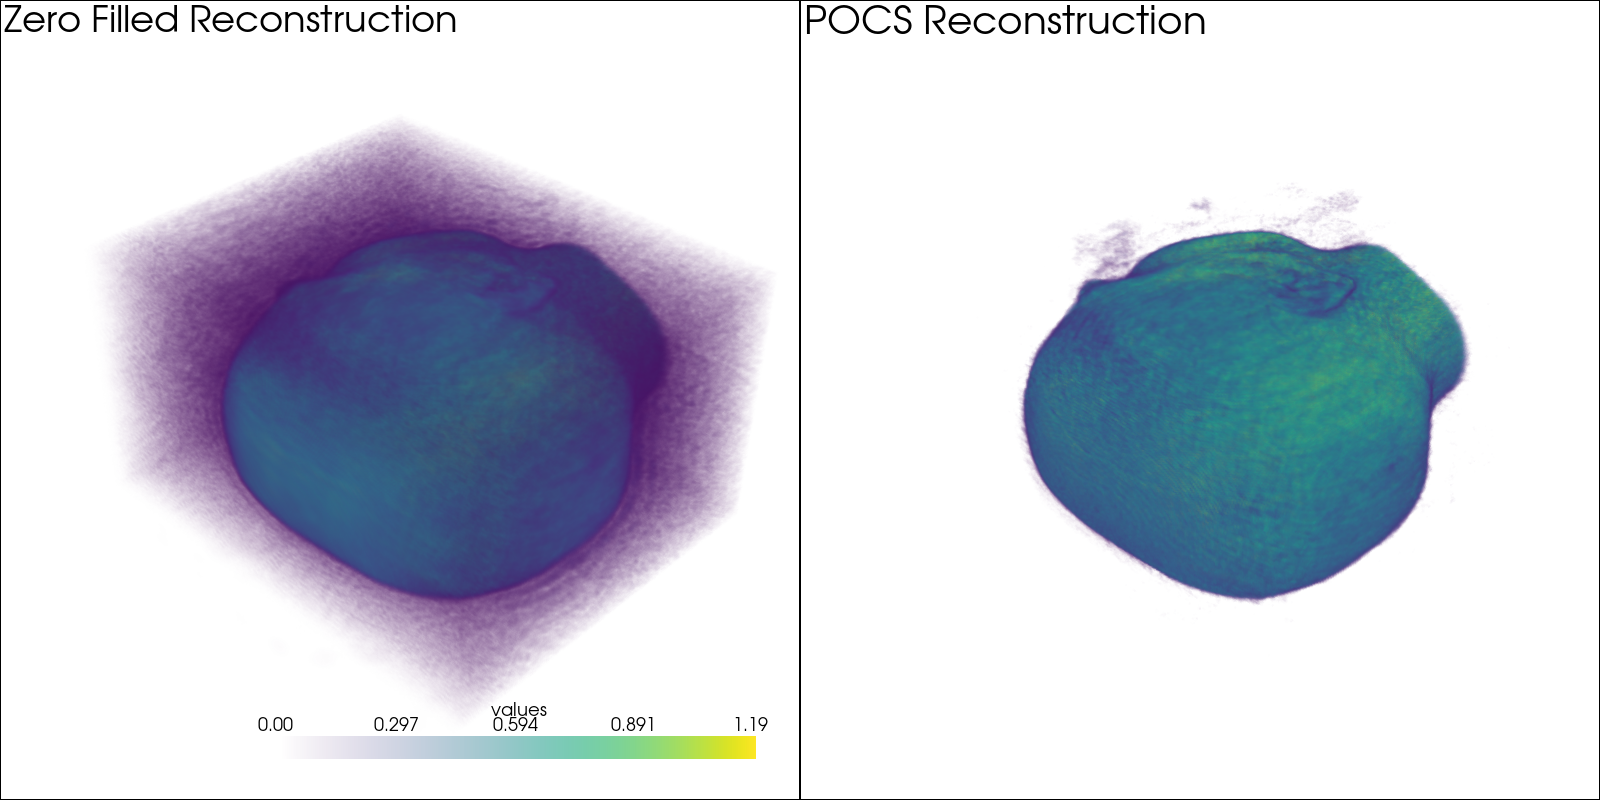

In [17]:
recon_pocs = np.clip(recon_pocs, 0, 1.0)  # 将数值限制在 [0, 1] 范围内
# recon_pocs[:,250:255,:] = 0.0
import pyvista as pv
plotter = pv.Plotter(shape=(1, 2), window_size=(1600, 800))

plotter.subplot(0, 0)
plotter.add_text("Zero Filled Reconstruction")
plotter.add_volume(recon, cmap="viridis")  # 可以指定colormap

plotter.subplot(0, 1)
plotter.add_text("POCS Reconstruction")
plotter.add_volume(recon_pocs, cmap="viridis")  # 可以指定colormap

plotter.show()

(256, 256, 150)

In [18]:
np.save('MRIdata/under/pocs_recon.npy',recon_pocs)

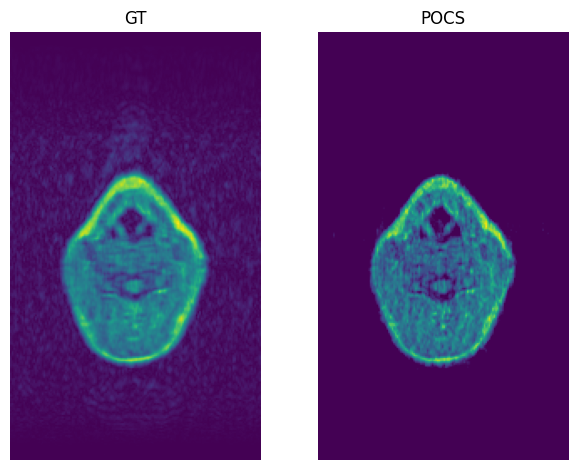

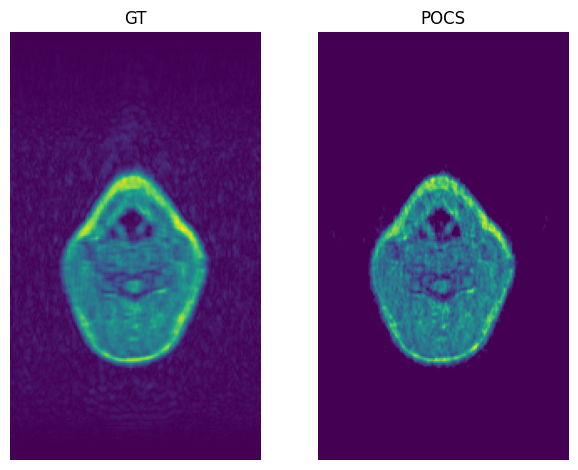

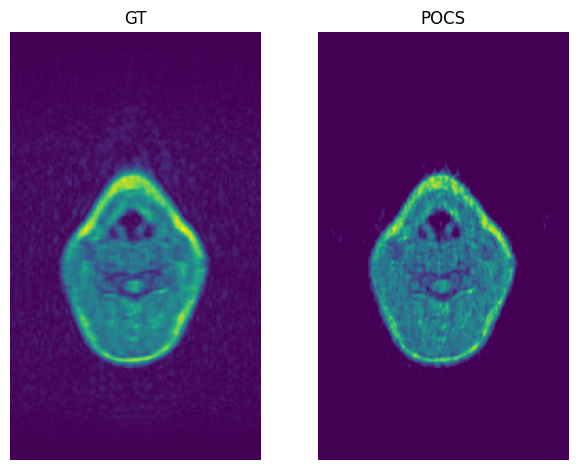

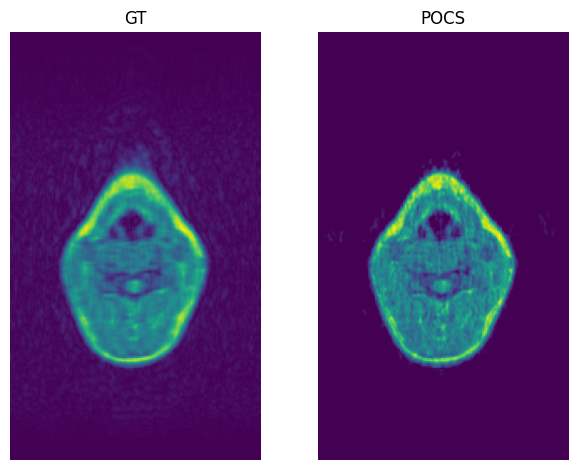

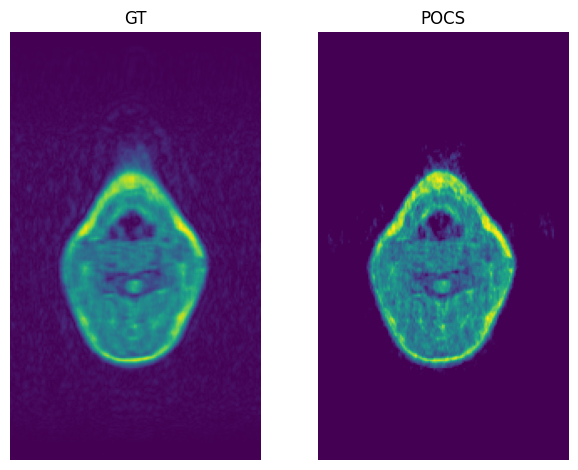

In [62]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(5):
    plt.figure()
    plt.subplot(1,2,1)
    plt.axis("off")
    plt.title("GT")
    plt.imshow(recon[:,i,:])

    plt.subplot(1,2,2)
    plt.axis("off")
    plt.title("POCS")
    plt.imshow(recon_pocs[:,i,:])

    plt.tight_layout()
    plt.show()

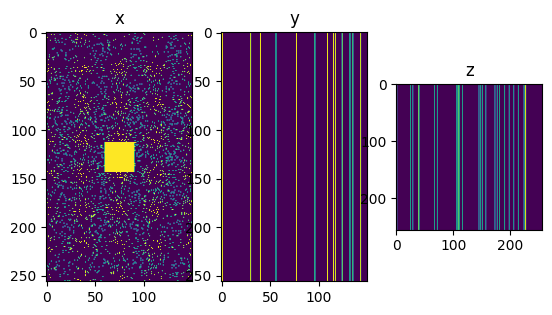

In [75]:
import matplotlib.pyplot as plt

plt.subplot(1,3,1)
plt.title("x")
plt.imshow(mask[0,...])

plt.subplot(1,3,2)
plt.title("y")
plt.imshow(mask[:,175,:])

plt.subplot(1,3,3)
plt.title("z")
plt.imshow(mask[...,100])

plt.show()